In [1]:
import random
import sympy

def generate_prime(bits):
    """Generate a secure prime number with given bit length."""
    return sympy.randprime(2**(bits-1), 2**bits)

def compute_gcd(a, b):
    """Calculate the greatest common divisor using Euclidean algorithm."""
    while b:
        a, b = b, a % b
    return a

def extended_gcd(a, b):
    """Find modular inverse using extended Euclidean method."""
    if a == 0:
        return b, 0, 1
    gcd, x1, y1 = extended_gcd(b % a, a)
    return gcd, y1 - (b // a) * x1, x1

def modular_inverse(e, totient):
    """Compute modular inverse of e mod totient."""
    gcd, x, _ = extended_gcd(e, totient)
    if gcd != 1:
        raise ValueError("Modular inverse does not exist")
    return x % totient

def generate_keys(bits):
    """Generate RSA public and private keys."""
    p = generate_prime(bits // 2)
    q = generate_prime(bits // 2)
    n = p * q
    phi = (p - 1) * (q - 1)
    e = 65537
    if compute_gcd(e, phi) != 1:
        raise ValueError("Invalid exponent selection")
    d = modular_inverse(e, phi)
    return (e, n), (d, n)

def encrypt(message, pub_key):
    """Encrypt a message using the public key."""
    e, n = pub_key
    return [pow(ord(ch), e, n) for ch in message]

def decrypt(cipher_text, priv_key):
    """Decrypt a message using the private key."""
    d, n = priv_key
    return "".join(chr(pow(chunk, d, n)) for chunk in cipher_text)

# Generate RSA keys
public_key, private_key = generate_keys(1024)

# Testing encryption and decryption
test_messages = [
    "B", "Hello World!", "Secure RSA Encryption Test",
    "The quick brown fox jumps over the lazy dog",
    "This is an extended message to verify proper encryption and decryption functions."
]

for idx, msg in enumerate(test_messages, 1):
    print(f"Test {idx}: Original -> {msg}")
    encrypted_msg = encrypt(msg, public_key)
    print(f"Encrypted: {encrypted_msg}")
    decrypted_msg = decrypt(encrypted_msg, private_key)
    print(f"Decrypted: {decrypted_msg}\n")
    assert msg == decrypted_msg, "Decryption did not return the original message!"
    print("Correct decryption\n")


In [ ]:
import time

key_sizes = [512, 1024, 2048, 4096]
generation_times = {}

for size in key_sizes:
    start_time = time.time()
    pub_key, priv_key = generate_keys(size)
    end_time = time.time()
    generation_times[size] = end_time - start_time
    print(f"RSA Key Size {size} bits -> Generated in {generation_times[size]:.2f} seconds")

RSA Key Size 512 bits -> Generated in 0.02 seconds
RSA Key Size 1024 bits -> Generated in 0.03 seconds
RSA Key Size 2048 bits -> Generated in 0.21 seconds
RSA Key Size 4096 bits -> Generated in 8.95 seconds


In [ ]:
import random
import sympy
import time
import numpy as np
import matplotlib.pyplot as plt

# Measure RSA key generation time for different key sizes
key_sizes = [512, 1024, 2048, 4096]
generation_times = {}

for size in key_sizes:
    start_time = time.time()
    pub_key, priv_key = generate_keys(size)
    end_time = time.time()
    generation_times[size] = end_time - start_time
    print(f"RSA Key Size {size} bits -> Generated in {generation_times[size]:.2f} seconds")

# Performance testing for encryption and decryption
def measure_rsa_performance(bits, msg_length):
    """Measure encryption and decryption times."""
    pub_key, priv_key = generate_keys(bits)
    msg = ''.join(np.random.choice(list("ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789"), msg_length))

    start_enc = time.time()
    encrypted_msg = encrypt(msg, pub_key)
    end_enc = time.time()
    enc_duration = end_enc - start_enc

    start_dec = time.time()
    decrypted_msg = decrypt(encrypted_msg, priv_key)
    end_dec = time.time()
    dec_duration = end_dec - start_dec

    return enc_duration, dec_duration

key_sizes = [1024, 2048, 4096]
message_sizes = [16, 128, 512, 1024]
performance_data = {}

for key in key_sizes:
    performance_data[key] = {}
    for msg_len in message_sizes:
        enc_time, dec_time = measure_rsa_performance(key, msg_len)
        performance_data[key][msg_len] = (enc_time, dec_time)
        print(f"Key: {key}-bit | Message: {msg_len} bytes | Encryption: {enc_time:.4f}s | Decryption: {dec_time:.4f}s")

RSA Key Size 512 bits -> Generated in 0.00 seconds
RSA Key Size 1024 bits -> Generated in 0.03 seconds
RSA Key Size 2048 bits -> Generated in 1.63 seconds
RSA Key Size 4096 bits -> Generated in 7.42 seconds
Key: 1024-bit | Message: 16 bytes | Encryption: 0.0006s | Decryption: 0.0811s
Key: 1024-bit | Message: 128 bytes | Encryption: 0.0047s | Decryption: 0.6578s
Key: 1024-bit | Message: 512 bytes | Encryption: 0.0192s | Decryption: 2.6321s
Key: 1024-bit | Message: 1024 bytes | Encryption: 0.0379s | Decryption: 5.3361s
Key: 2048-bit | Message: 16 bytes | Encryption: 0.0025s | Decryption: 1.0404s
Key: 2048-bit | Message: 128 bytes | Encryption: 0.0136s | Decryption: 4.3311s
Key: 2048-bit | Message: 512 bytes | Encryption: 0.0553s | Decryption: 17.9870s
Key: 2048-bit | Message: 1024 bytes | Encryption: 0.1453s | Decryption: 35.6581s
Key: 4096-bit | Message: 16 bytes | Encryption: 0.0052s | Decryption: 3.7983s
Key: 4096-bit | Message: 128 bytes | Encryption: 0.0557s | Decryption: 32.2574s
K

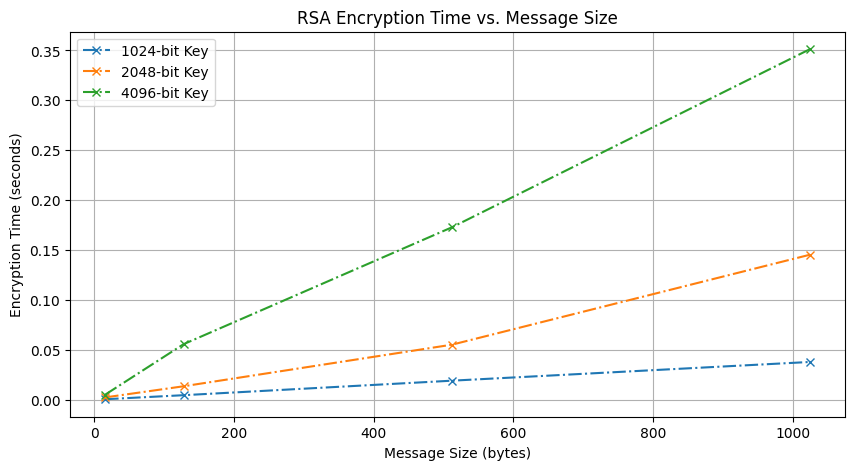

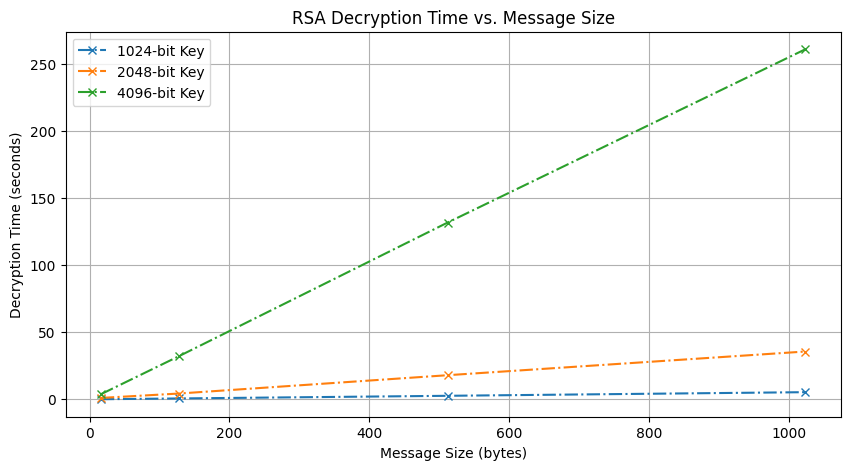

In [ ]:
enc_times = [[performance_data[k][m][0] for m in message_sizes] for k in key_sizes]
dec_times = [[performance_data[k][m][1] for m in message_sizes] for k in key_sizes]

plt.figure(figsize=(10, 5))
for i, key in enumerate(key_sizes):
    plt.plot(message_sizes, enc_times[i], marker='x',linestyle='dashdot', label=f'{key}-bit Key')
plt.xlabel("Message Size (bytes)")
plt.ylabel("Encryption Time (seconds)")
plt.title("RSA Encryption Time vs. Message Size")
plt.legend()
plt.grid(True)

plt.show()

plt.figure(figsize=(10, 5))
for i, key in enumerate(key_sizes):
    plt.plot(message_sizes, dec_times[i], marker='x', linestyle='dashdot', label=f'{key}-bit Key')
plt.xlabel("Message Size (bytes)")
plt.ylabel("Decryption Time (seconds)")
plt.title("RSA Decryption Time vs. Message Size")
plt.legend()
plt.grid(True)
plt.show()
